In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

sns.set(style="whitegrid")

In [ ]:
import re
import matplotlib.pyplot as plt

log_path = "/projects/e32998/STAT390_Winter2026/Team2/Code/Code_Pres3_Roma/roma_logs/test2.out"

train_losses = []
val_losses = []
lrs = []

# FIXED pattern: use \| instead of comma
loss_pattern = re.compile(
    r"Train Loss:\s*([0-9eE\.\-]+)\s*\|\s*Val Loss:\s*([0-9eE\.\-]+)"
)

lr_pattern = re.compile(
    r"Epoch\s*\d+/\d+\s*\(LR:\s*([0-9eE\.\-]+)\)"
)

with open(log_path, "r") as f:
    for line in f:
        lr_match = lr_pattern.search(line)
        if lr_match:
            lrs.append(float(lr_match.group(1)))

        loss_match = loss_pattern.search(line)
        if loss_match:
            train_losses.append(float(loss_match.group(1)))
            val_losses.append(float(loss_match.group(2)))

if len(train_losses) == 0:
    raise ValueError("No Train/Val loss found. Check log format.")

epochs = list(range(1, len(train_losses) + 1))

# =============================
# PLOTTING
# =============================

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=150)

# Loss curves
ax1.plot(epochs, train_losses, label="Train Loss", linewidth=2)
ax1.plot(epochs, val_losses, label="Val Loss", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xticks(epochs)
ax1.grid(True, linestyle="--", alpha=0.6)

# Learning rate on second axis
ax2 = ax1.twinx()
ax2.plot(epochs[:len(lrs)], lrs, linestyle="--", linewidth=2, label="Learning Rate")
ax2.set_ylabel("Learning Rate")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Training/Validation Loss and Learning Rate")
plt.tight_layout()
plt.show()

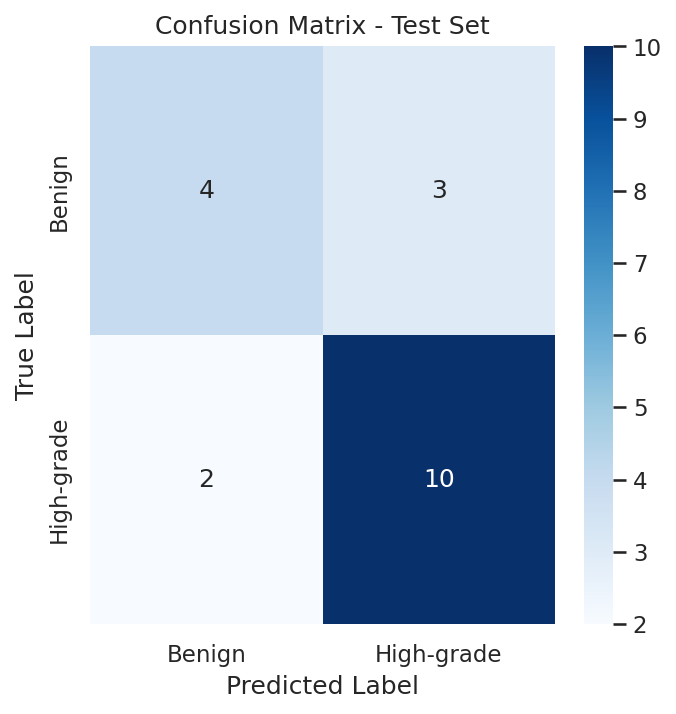

In [2]:
pred_df = pd.read_csv(
    "/projects/e32998/MIL_training/final_runs/run_20260228_231215/predictions.csv"
)

y_true = pred_df["true_label"]
y_pred = pred_df["predicted_label"]

cm = confusion_matrix(y_true, y_pred)

class_labels = ["Benign", "High-grade"]

plt.figure(figsize=(5,5), dpi=150)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()

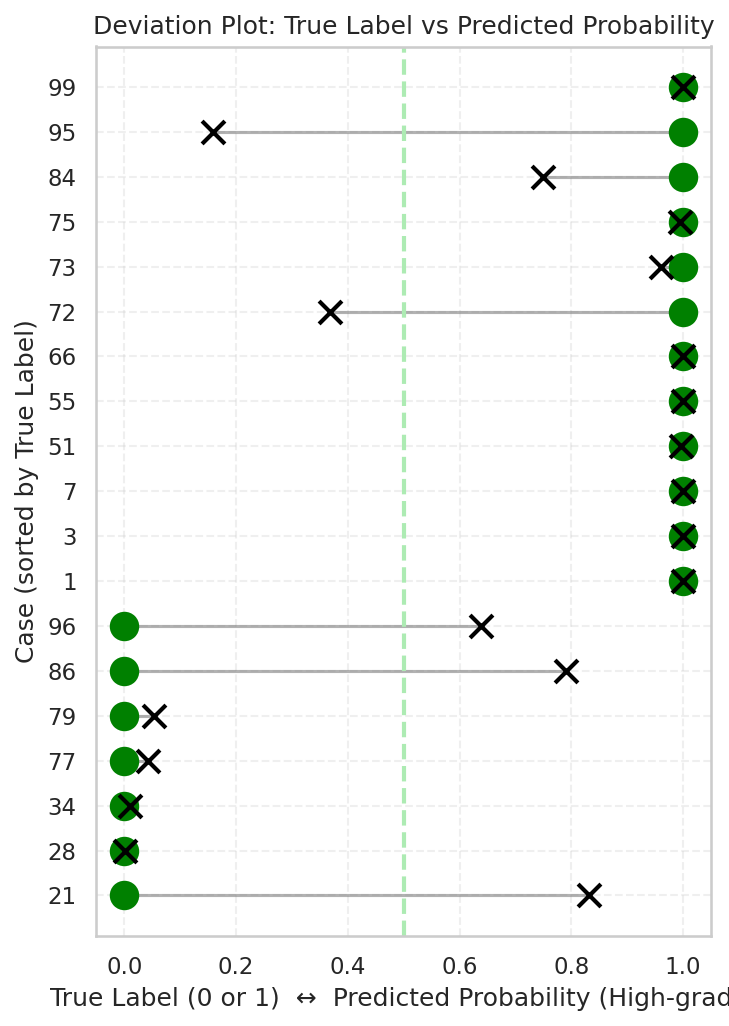

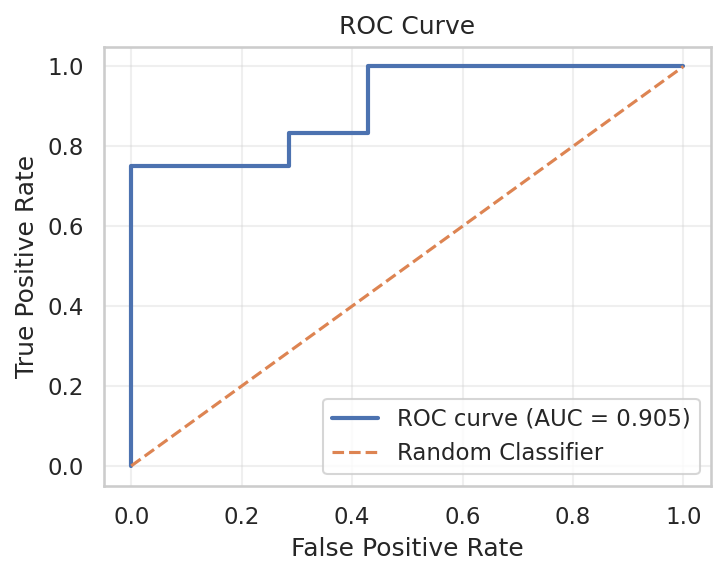


Computed AUC = 0.905


In [3]:
# Load predictions
pred_df = pd.read_csv(
    "/projects/e32998/MIL_training/final_runs/run_20260228_231215/predictions.csv"
)

# Use correct probability column
pred_df["prob_high_grade"] = pred_df["prob_class1"]

# =====================================================
# 3. DEVIATION PLOT
# =====================================================

pred_df_sorted = pred_df.sort_values(["true_label", "case_id"]).reset_index(drop=True)
pred_df_sorted["case_str"] = pred_df_sorted["case_id"].astype(str)

plt.figure(figsize=(5,7), dpi=150)

for i, row in pred_df_sorted.iterrows():

    # connecting line
    plt.plot(
        [row["true_label"], row["prob_high_grade"]],
        [i, i],
        color="gray",
        alpha=0.6,
        linewidth=1.5
    )

    # true label (green circle)
    plt.scatter(
        row["true_label"], i,
        color="green",
        s=200,
        marker="o",
        edgecolor="black",
        linewidth=0,
        zorder=3
    )

    # predicted probability (black X)
    plt.scatter(
        row["prob_high_grade"], i,
        color="black",
        s=120,
        marker="x",
        linewidths=2,
        zorder=4
    )

plt.yticks(range(len(pred_df_sorted)), pred_df_sorted["case_str"])
plt.axvline(0.5, color="#ADEBB3", linestyle="--", linewidth=2,
            label="Decision Threshold (0.5)")
plt.xlabel("True Label (0 or 1)  ↔  Predicted Probability (High-grade)")
plt.ylabel("Case (sorted by True Label)")
plt.title("Deviation Plot: True Label vs Predicted Probability")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# =====================================================
# ROC / AUC
# =====================================================

fpr, tpr, thresholds = roc_curve(
    pred_df["true_label"],
    pred_df["prob_high_grade"]
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4), dpi=150)
plt.plot(
    fpr, tpr,
    lw=2,
    label=f'ROC curve (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1], [0, 1],
    lw=1.5,
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nComputed AUC = {roc_auc:.3f}")

Total misclassified benign cases: 3

--- Case 21 ---


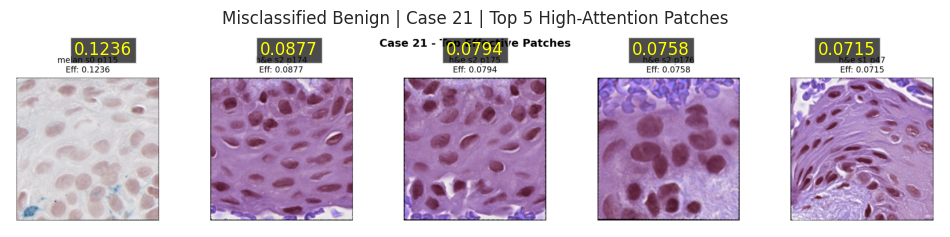


--- Case 86 ---


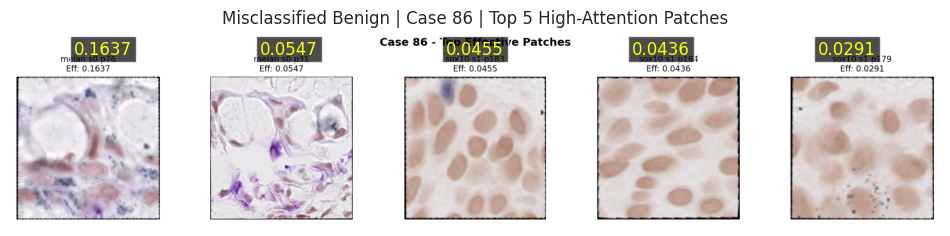


--- Case 96 ---


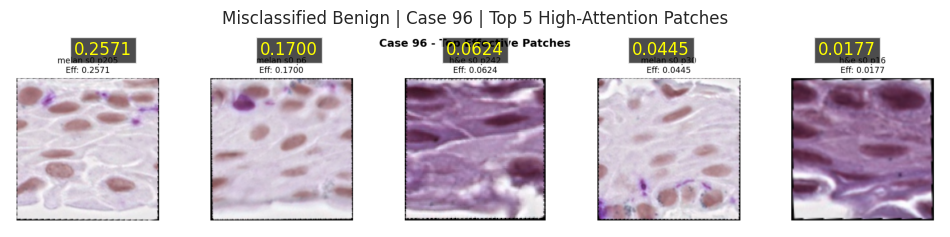

In [4]:
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------
# Paths
# -------------------------------------------------
RUN_DIR = "/projects/e32998/MIL_training/final_runs/run_20260228_231215"
ATTN_CSV = os.path.join(RUN_DIR, "attention_analysis/top_effective_patches_per_case_5.0pct.csv")
MISCLASS_CSV = os.path.join(RUN_DIR, "misclassified_benign_cases.csv")
BASE_DIR = os.path.join(RUN_DIR, "attention_analysis/case_effective_patches")

# -------------------------------------------------
# Load Data
# -------------------------------------------------
attn_df = pd.read_csv(ATTN_CSV)
misclass_df = pd.read_csv(MISCLASS_CSV)

misclassified_ids = misclass_df["case_id"].tolist()

# Keep only misclassified benign
misclassified_benign = attn_df[
    (attn_df["case_id"].isin(misclassified_ids)) &
    (attn_df["true_label"] == 0) &
    (attn_df["pred_label"] == 1)
]

print(f"Total misclassified benign cases: {len(misclassified_ids)}")

# -------------------------------------------------
# Visualization
# -------------------------------------------------
def show_high_attention(case_id, k=5):
    
    case_df = misclassified_benign[
        misclassified_benign["case_id"] == case_id
    ]
    
    if len(case_df) == 0:
        print(f"No attention data for case {case_id}")
        return
    
    # Sort by effective weight (HIGH attention only)
    case_df = case_df.sort_values(
        "effective_weight", ascending=False
    ).head(k)
    
    img_path = os.path.join(
        BASE_DIR,
        f"case_{case_id}_top_effective_patches.png"
    )
    
    if not os.path.exists(img_path):
        print("Missing:", img_path)
        return
    
    img = Image.open(img_path)
    img_array = np.array(img)
    
    plt.figure(figsize=(12, 3))
    plt.imshow(img_array)
    plt.axis("off")
    
    h, w, _ = img_array.shape
    patch_width = w / k
    
    for i, row in enumerate(case_df.itertuples()):
        x = patch_width * i + patch_width / 2
        y = 20
        
        plt.text(
            x, y,
            f"{row.effective_weight:.4f}",
            color="yellow",
            fontsize=12,
            ha="center",
            va="top",
            bbox=dict(facecolor="black", alpha=0.7, pad=3)
        )
    
    plt.title(f"Misclassified Benign | Case {case_id} | Top {k} High-Attention Patches")
    plt.show()


# -------------------------------------------------
# Run for all misclassified benign cases
# -------------------------------------------------
for case_id in misclassified_ids:
    print(f"\n--- Case {case_id} ---")
    show_high_attention(case_id, k=5)

Total patches in case 21: 710
High-grade predicted patches: 65
Percentage high-grade: 9.15 %

Top 5 most confident high-grade patches:
                               patch_name  prob_highgrade
2523  case_21_unmatched_3_h&e_patch97.png        0.999999
2520  case_21_unmatched_3_h&e_patch94.png        0.999998
2522  case_21_unmatched_3_h&e_patch96.png        0.999984
2521  case_21_unmatched_3_h&e_patch95.png        0.999972
2524  case_21_unmatched_3_h&e_patch98.png        0.999516

High-grade probability statistics:
count    65.000000
mean      0.734430
std       0.158775
min       0.507536
25%       0.595778
50%       0.714756
75%       0.866505
max       0.999999
Name: prob_highgrade, dtype: float64


/tmp/ipykernel_2049303/2703190257.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  case_21_high["patch_name"] = case_21_high["patch_path"].apply(os.path.basename)


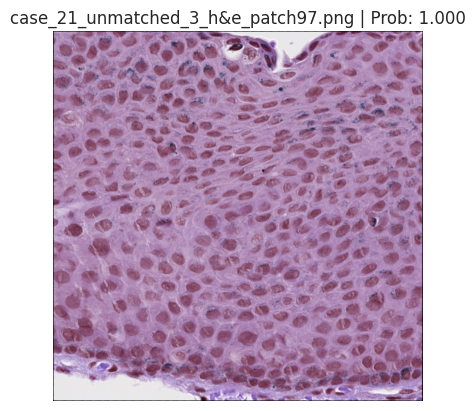

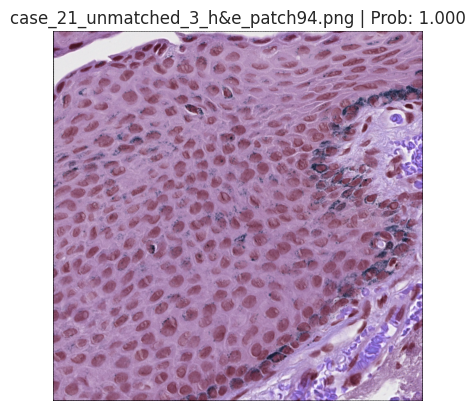

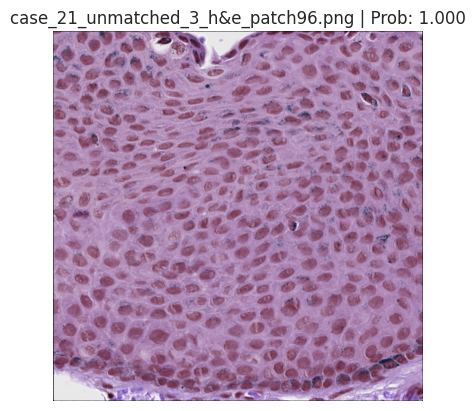

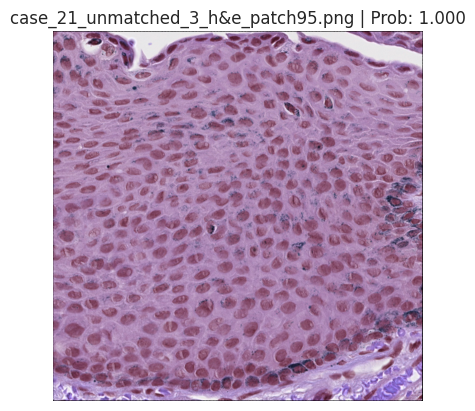

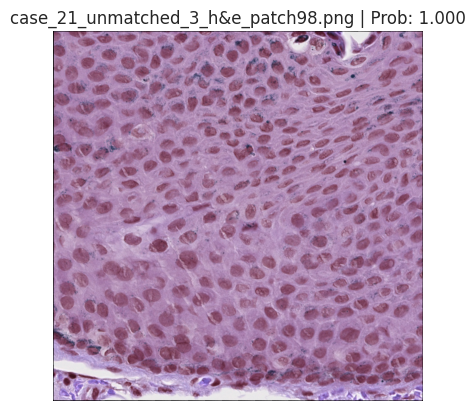

In [5]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

# ============================
# PATH
# ============================
pred_path = "/projects/e32998/MIL_training/final_runs/run_20260228_231215/patch_predictions.csv"

# ============================
# LOAD DATA
# ============================
df = pd.read_csv(pred_path)

# ============================
# FILTER CASE 21
# ============================
case_21 = df[df["case_id"] == 21]
case_21_high = case_21[case_21["predicted"] == 1]

print("Total patches in case 21:", len(case_21))
print("High-grade predicted patches:", len(case_21_high))
print("Percentage high-grade:",
      round(len(case_21_high) / len(case_21) * 100, 2), "%")

# ============================
# ADD PATCH NAME COLUMN
# ============================
case_21_high["patch_name"] = case_21_high["patch_path"].apply(os.path.basename)

# ============================
# SORT BY CONFIDENCE
# ============================
case_21_high = case_21_high.sort_values(
    by="prob_highgrade",
    ascending=False
)

print("\nTop 5 most confident high-grade patches:")
print(case_21_high[["patch_name", "prob_highgrade"]].head())

# ============================
# PROBABILITY STATS
# ============================
print("\nHigh-grade probability statistics:")
print(case_21_high["prob_highgrade"].describe())

# ============================
# OPTIONAL: VISUALIZE TOP 5 PATCHES
# ============================
for _, row in case_21_high.head(5).iterrows():
    path = row["patch_path"]
    if os.path.exists(path):
        img = Image.open(path)
        plt.imshow(img)
        plt.title(f"{row['patch_name']} | Prob: {row['prob_highgrade']:.3f}")
        plt.axis("off")
        plt.show()

Total patches in case 21: 710
High-grade predicted patches: 65
Percentage high-grade: 9.15 %

Top 5 most confident high-grade patches:
                               patch_name  prob_highgrade
2523  case_21_unmatched_3_h&e_patch97.png        0.999999
2520  case_21_unmatched_3_h&e_patch94.png        0.999998
2522  case_21_unmatched_3_h&e_patch96.png        0.999984
2521  case_21_unmatched_3_h&e_patch95.png        0.999972
2524  case_21_unmatched_3_h&e_patch98.png        0.999516

High-grade probability statistics:
count    65.000000
mean      0.734430
std       0.158775
min       0.507536
25%       0.595778
50%       0.714756
75%       0.866505
max       0.999999
Name: prob_highgrade, dtype: float64


/tmp/ipykernel_2049303/2703190257.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  case_21_high["patch_name"] = case_21_high["patch_path"].apply(os.path.basename)


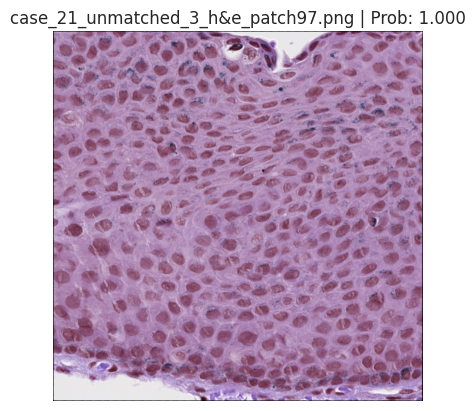

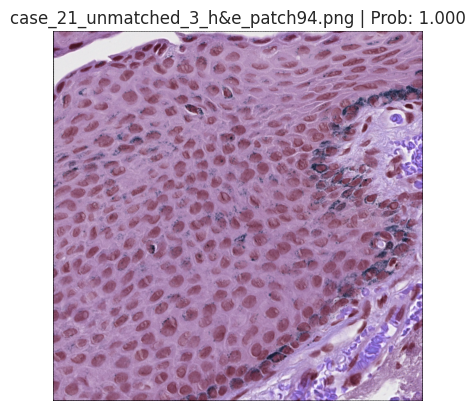

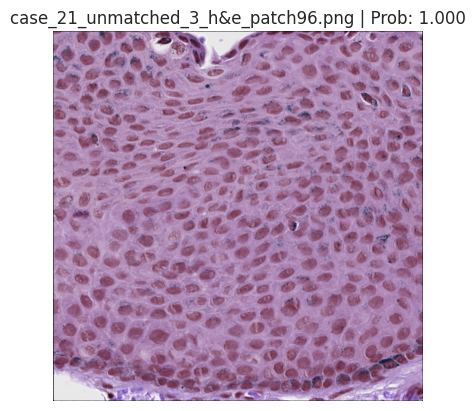

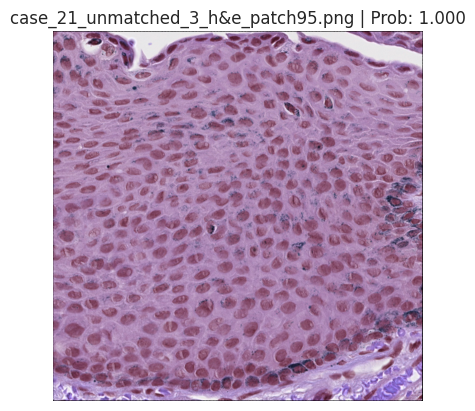

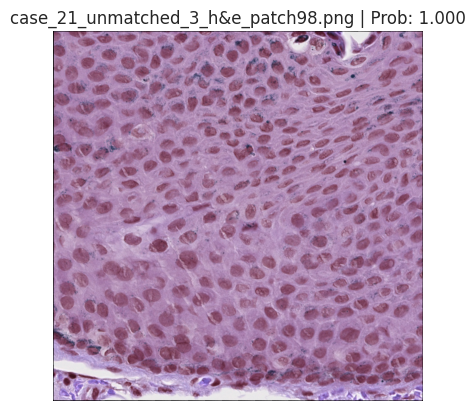

In [6]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

# ============================
# PATH
# ============================
pred_path = "/projects/e32998/MIL_training/final_runs/run_20260228_231215/patch_predictions.csv"

# ============================
# LOAD DATA
# ============================
df = pd.read_csv(pred_path)

# ============================
# FILTER CASE 21
# ============================
case_21 = df[df["case_id"] == 21]
case_21_high = case_21[case_21["predicted"] == 1]

print("Total patches in case 21:", len(case_21))
print("High-grade predicted patches:", len(case_21_high))
print("Percentage high-grade:",
      round(len(case_21_high) / len(case_21) * 100, 2), "%")

# ============================
# ADD PATCH NAME COLUMN
# ============================
case_21_high["patch_name"] = case_21_high["patch_path"].apply(os.path.basename)

# ============================
# SORT BY CONFIDENCE
# ============================
case_21_high = case_21_high.sort_values(
    by="prob_highgrade",
    ascending=False
)

print("\nTop 5 most confident high-grade patches:")
print(case_21_high[["patch_name", "prob_highgrade"]].head())

# ============================
# PROBABILITY STATS
# ============================
print("\nHigh-grade probability statistics:")
print(case_21_high["prob_highgrade"].describe())

# ============================
# OPTIONAL: VISUALIZE TOP 5 PATCHES
# ============================
for _, row in case_21_high.head(5).iterrows():
    path = row["patch_path"]
    if os.path.exists(path):
        img = Image.open(path)
        plt.imshow(img)
        plt.title(f"{row['patch_name']} | Prob: {row['prob_highgrade']:.3f}")
        plt.axis("off")
        plt.show()